<a href="https://colab.research.google.com/github/Muzsek/Weather/blob/main/Budapest_Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install meteostat --upgrade scikit-learn

In [2]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from meteostat import Daily, Point
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
city = Point(lat = 47.49801, lon = 19.04023)

start = datetime(year = 2015, month = 1, day = 1)
end = datetime(year = 2025, month = 9, day = 26)

data = Daily(loc = city, start = start, end = end)
data = data.fetch()
print(data.head())

            tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  pres  tsun
time                                                                  
2015-01-01  -4.8  -9.2  -2.6  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>
2015-01-02  -1.2  -2.9   0.9  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>
2015-01-03   3.9   0.0   6.6  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>
2015-01-04   2.3   0.1   4.7   3.3   1.0  <NA>  <NA>  <NA>  <NA>  <NA>
2015-01-05   1.4   0.4   2.9   0.0  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>


In [4]:
print("Adatok kezdete:", data.index.min())
print("Adatok vége:", data.index.max(),"\n")

df_2025 = data[data.index.year == 2025]
print(df_2025)

Adatok kezdete: 2015-01-01 00:00:00
Adatok vége: 2025-09-26 00:00:00 

            tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt    pres  tsun
time                                                                    
2025-01-01  -2.7  -3.5  -2.2   0.0  <NA>  <NA>   2.9  14.8  1030.7  <NA>
2025-01-02  -0.6  -3.4   2.0   0.0  <NA>  <NA>   5.2  20.4  1018.8  <NA>
2025-01-03   1.1   0.5   1.9   3.1  <NA>  <NA>  16.4  33.3  1015.6  <NA>
2025-01-04  -0.1  -2.7   1.4   0.0  <NA>  <NA>  14.1  33.3  1022.5  <NA>
2025-01-05  -1.6  -3.4   0.1   0.5  <NA>  <NA>   7.7  24.1  1016.7  <NA>
...          ...   ...   ...   ...   ...   ...   ...   ...     ...   ...
2025-09-22  21.4  15.8  28.5   0.0  <NA>  <NA>   3.9  27.8  1013.7  <NA>
2025-09-23  20.2  15.9  25.8   0.0  <NA>  <NA>   3.4  24.1  1014.8  <NA>
2025-09-24  18.6  15.4  23.6   0.0  <NA>  <NA>   6.4  27.8  1016.8  <NA>
2025-09-25  16.8  13.9  20.6   0.0  <NA>  <NA>   7.2  31.5  1018.1  <NA>
2025-09-26  14.4  11.8  16.9   0.0  <NA>  <NA>   6.7 

In [5]:
df = data[["tavg"]].dropna().reset_index()
df.rename(columns={"time":"date","tavg":"avg_temp"}, inplace=True)
df.head()

,date,avg_temp
0,2015-01-01,-4.8
1,2015-01-02,-1.2
2,2015-01-03,3.9
3,2015-01-04,2.3
4,2015-01-05,1.4


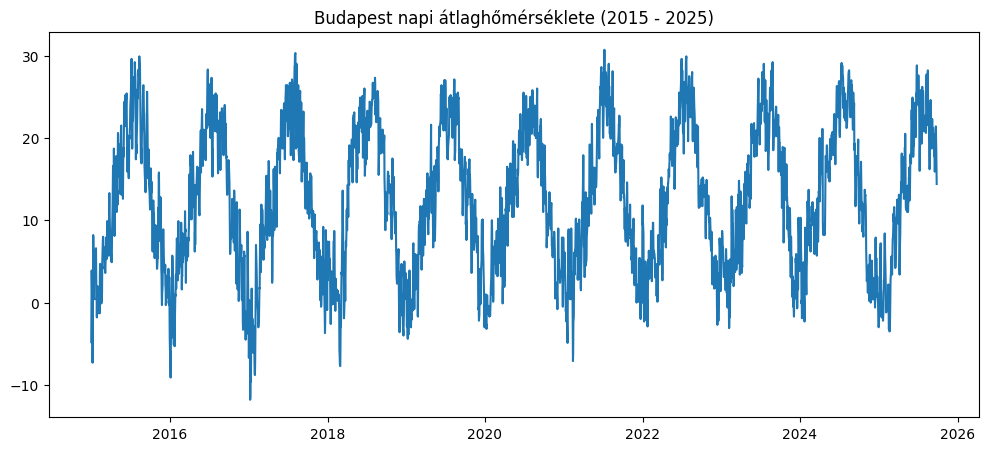

In [6]:
plt.figure(figsize = (12,5))
plt.plot(df["date"], df["avg_temp"])
plt.title("Budapest napi átlaghőmérséklete (2015 - 2025)")
plt.show()

In [7]:
window_size = 7
horizon = 1

values = df["avg_temp"].values
X, y = [],[]

for i in range(len(values) - window_size - horizon):
  X.append(values[i:i+window_size])
  y.append(values[i+window_size+horizon])

X = np.array(X)
y = np.array(y)

print("X shape: ", X.shape)
print("y shape: ", y.shape)

split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

print("Train: ", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

X shape:  (3910, 7)
y shape:  (3910,)
Train:  (3128, 7) (3128,)
Test:  (782, 7) (782,)


In [9]:
### Baseline

naive_preds = X_test[:,-1]

mae = mean_absolute_error(y_test, naive_preds)
rmse = np.sqrt(mean_squared_error(y_test, naive_preds))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2.22
RMSE: 2.86
